# Spotify Track Genre Classification
## Classificazione multiclass del genere musicale

**Programmazione di Applicazioni Data Intensive**  
Laurea in Ingegneria e Scienze Informatiche  
DISI - Università di Bologna, Cesena

Si deve realizzare un modello di classificazione che, utilizzando le feature audio estratte dall'API Spotify (energia, danceability, valence, acousticness, ecc.), sia in grado di predire il genere musicale di una traccia.

Il dataset Spotify contiene 114,000 tracce distribuite su 114 generi diversi, con feature numeriche che caratterizzano proprietà fisiche e percettive della musica.

Il dataset usato nel notebook e` `maharshipandya/spotify-tracks-dataset`, scaricato da HuggingFace e basato su feature audio rese disponibili da Spotify. Vengono importate le librerie necessarie per scaricare il dataset, organizzare le strutture dati e creare visualizzazioni.

### Importazione librerie

In [179]:
%pip install datasets scikit-learn seaborn -q

Note: you may need to restart the kernel to use updated packages.


In [180]:
from datasets import load_dataset
%matplotlib inline
import os.path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split

### Caricamento dei dati

In [181]:
file = 'spotify_tracks.csv'
if not os.path.exists('spotify_tracks.csv'):
    print('Downloading Spotify dataset...')
    dataset = load_dataset('maharshipandya/spotify-tracks-dataset')
    df_genre = pd.DataFrame(dataset['train'])
    print(f'Dataset scaricato!')
    print(f'Shape: {df_genre.shape}')
    df_genre.to_csv(file, index=False)
    print(f'\nDataset salvato in: {file}')
else:
    print('Dataset già presente. Caricamento da file...')
    df_genre = pd.read_csv(file)
    print(f'Dataset caricato da: {file}')
    print(f'Shape: {df_genre.shape}')

Dataset già presente. Caricamento da file...
Dataset caricato da: spotify_tracks.csv
Shape: (114000, 21)


Visualizzo ora le prime righe del dataset:

In [182]:
df_genre.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Descrizione delle feature

Il dataset Spotify contiene le seguenti colonne:

**Metadati:**
- `track_id`: ID univoco della traccia su Spotify
- `artists`: Nomi degli artisti (se più artisti, separati da ';')
- `album_name`: Nome dell'album
- `track_name`: Nome della traccia

**Feature Audio :**
- `popularity`: Popolarità (0-100) calcolata da Spotify; valori più alti indicano brani più ascoltati recentemente
- `duration_ms`: Durata della traccia in millisecondi
- `explicit`: Contenuto esplicito? (true = sì; false = no o sconosciuto)
- `danceability`: Indice (0.0-1.0) che misura quanto la traccia è adatta al ballo
- `energy`: Indice (0.0-1.0) di intensità/energia percepita
- `key`: Tonalità (0=C, 1=C♯/D♭, 2=D, ...). -1 se non rilevata
- `loudness`: Loudness complessiva in decibel (dB)
- `mode`: Modalità (1 = maggiore, 0 = minore)
- `speechiness`: Presenza di parlato (valori >0.66 indicano probabile parlato puro; 0.33-0.66 indicano mix)
- `acousticness`: Confidenza che la traccia sia acustica (0.0-1.0)
- `instrumentalness`: Probabilità che la traccia sia strumentale (più alto = più probabile assenza di vocali)
- `liveness`: Probabilità che la traccia sia registrata dal vivo (valori >0.8 indicano performance live)
- `valence`: Indice (0.0-1.0) di positività emotiva della traccia (alto = più allegra)
- `tempo`: Tempo stimato in battiti per minuto (BPM)
- `time_signature`: Firma ritmica stimata (3-7, es. 4 => 4/4)
- `track_genre`: Genere della traccia

Separo id, nome album e artista perché non portano informazioni utili al riconoscimento del genere: il modello deve riconsocere il genere a prescidere dall'album e da chi suona

In [183]:
feature_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 'explicit',
                'key', 'loudness', 'mode', 'speechiness', 'acousticness',
                'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
genre_col = 'track_genre'

metadata_cols = ['track_id', 'track_name', 'artists', 'album_name']

metadata = df_genre[metadata_cols].copy()
df_genre = df_genre[feature_cols + [genre_col]].copy()

Controllo le righe che contengono valori null:

In [184]:
df_genre.isnull().sum()

popularity          0
duration_ms         0
danceability        0
energy              0
explicit            0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Non ci sono rows che hanno valori null, per cui non faccio nulla

## 2 - Analisi Esplorativa




Con il metodo describe() è possibile avere una rappresentazione statistica delle feature numeriche, ottenendo media, deviazione standard e la distribuzione in termini di massimi, minimi e percentili.

In [185]:
df_genre.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


L'**energia** e la **danceability** mostrano una distribuzione ampia e variegata, suggerendo che questi attributi sono fortemente caratterizzanti per la discriminazione tra generi diversi; brani energici e danzabili tendono a concentrarsi in generi specifici (pop, dance, electronic), mentre brani meno energici caratterizzano generi come lo slowcore o il folk. 

La **valence** (positività emotiva) presenta una distribuzione diffusa su tutto lo spettro (0.0-1.0), il che indica che questo parametro è un discriminante importante nel classificare generi melanconici versus generi più positivi e vivaci. Il **tempo** (BPM) varia considerevolmente tra le tracce, evidenziando come generi diversi abbiano velocità caratteristiche: generi veloci come l'EDM e il punk contrastano con generi lenti come il jazz ballad o il blues.

La **popolarità** si concentra su valori medio-bassi, indicando che il modello avrà accesso a una varietà di generi sia mainstream che di nicchia.

Feature come **acousticness** e **instrumentalness** mostrano distribuzioni asimmetriche con valori generalmente bassi, riflettendo il predominio di musica prodotta elettronicamente e vocale nel dataset, tuttavia i picchi in queste feature permetteranno di identificare generi specifici come l'acoustic folk o il jazz strumentale.

L'**intelligibilità del parlato** (speechiness) rimane bassa nella maggior parte delle tracce, ma la presenza di outlier potrebbe aiutare a identificare generi come il rap o il spoken word.

### Analisi del target: track_genre

In [186]:
# Stampa l'elenco completo dei generi unici ordinati alfabeticamente
generi_completi = sorted(df_genre['track_genre'].unique())
print(f"Ci sono {len(generi_completi)} generi totali:\n")
for g in generi_completi:
    print(g)


Ci sono 114 generi totali:

acoustic
afrobeat
alt-rock
alternative
ambient
anime
black-metal
bluegrass
blues
brazil
breakbeat
british
cantopop
chicago-house
children
chill
classical
club
comedy
country
dance
dancehall
death-metal
deep-house
detroit-techno
disco
disney
drum-and-bass
dub
dubstep
edm
electro
electronic
emo
folk
forro
french
funk
garage
german
gospel
goth
grindcore
groove
grunge
guitar
happy
hard-rock
hardcore
hardstyle
heavy-metal
hip-hop
honky-tonk
house
idm
indian
indie
indie-pop
industrial
iranian
j-dance
j-idol
j-pop
j-rock
jazz
k-pop
kids
latin
latino
malay
mandopop
metal
metalcore
minimal-techno
mpb
new-age
opera
pagode
party
piano
pop
pop-film
power-pop
progressive-house
psych-rock
punk
punk-rock
r-n-b
reggae
reggaeton
rock
rock-n-roll
rockabilly
romance
sad
salsa
samba
sertanejo
show-tunes
singer-songwriter
ska
sleep
songwriter
soul
spanish
study
swedish
synth-pop
tango
techno
trance
trip-hop
turkish
world-music


Si può fare un'ulteriore passo raggruppando sotto un'unica etichetta quei generi che sono sottogeneri di un "macro-genere" come può essere l'alt-rock per il rock.

In [187]:

macrogeneri_clean = {
    "Rock, Punk & Hardcore": [
        "alt-rock", "alternative", "grunge", "hard-rock", "indie", "psych-rock", 
        "rock", "rock-n-roll", "rockabilly", "j-rock", "emo", "goth", "hardcore", "punk", "punk-rock", "ska"
    ],
    
    "Metal": ["black-metal", "death-metal", "grindcore", "heavy-metal", "industrial", "metal", "metalcore"],
    
    "Pop": ["pop", "indie-pop", "power-pop", "synth-pop", "cantopop", "j-pop", "k-pop", "mandopop", "j-idol", "pop-film", "anime", "disney", "show-tunes"],
    
    "Electronic, Dance & Club": [
        "club", "dance", "disco", "house", "chicago-house", "deep-house", "progressive-house", "hardstyle", "garage", "j-dance",
        "electronic", "breakbeat", "detroit-techno", "drum-and-bass", "dub", "dubstep", "edm", "electro", "idm", "minimal-techno", 
        "techno", "trance", "trip-hop", "ambient", "chill"
    ],
    
    "Hip-Hop, R&B & Soul": ["hip-hop", "r-n-b", "soul", "funk", "gospel", "groove"],
    
    "Jazz & Blues": ["jazz", "blues"],
    
    "Folk & Country": ["acoustic", "bluegrass", "country", "folk", "forro", "honky-tonk", "singer-songwriter", "songwriter", "guitar"],
    "Classical": ["classical", "opera", "piano", "new-age"]

}

# 1. Crei il dizionario invertito per i macrogeneri
genere_to_macro = {sotto_genere: macro for macro, sotto_generi in macrogeneri_clean.items() for sotto_genere in sotto_generi}

df = df_genre.copy()
# 2. Mappi la colonna nel DataFrame
df['genre'] = df['track_genre'].map(genere_to_macro)

# 3. ELIMINI LE RIGHE che non hanno trovato una corrispondenza
df = df.drop(columns="track_genre")
df = df.dropna(subset=['genre'])

print(f"Righe dopo la pulizia: {len(df)}")

Righe dopo la pulizia: 82000


Trasformo la feature explicit (bool) in 0 e 1

In [188]:
df['explicit'] = df['explicit'].astype(int)

### Analisi della distribuzione dei generi

Il dataset originario aveva esattamente 1000 tracce per genere. Controlliamo invece dopo la suddivisione in macrogenere:

In [189]:
genres = df['genre'].value_counts()
print(f'\nNumero di tracce per macrogenere:')
print(genres.head(20))


Numero di tracce per macrogenere:
genre
Electronic, Dance & Club    25000
Rock, Punk & Hardcore       16000
Pop                         13000
Folk & Country               9000
Metal                        7000
Hip-Hop, R&B & Soul          6000
Classical                    4000
Jazz & Blues                 2000
Name: count, dtype: int64


In questo caso la distribuzione è sbilanciata e si dovrà agire per contrastare il problema

### Distribuzioni individuali delle feature

Passiamo ora ad analizzare la distibuzione delle feature:

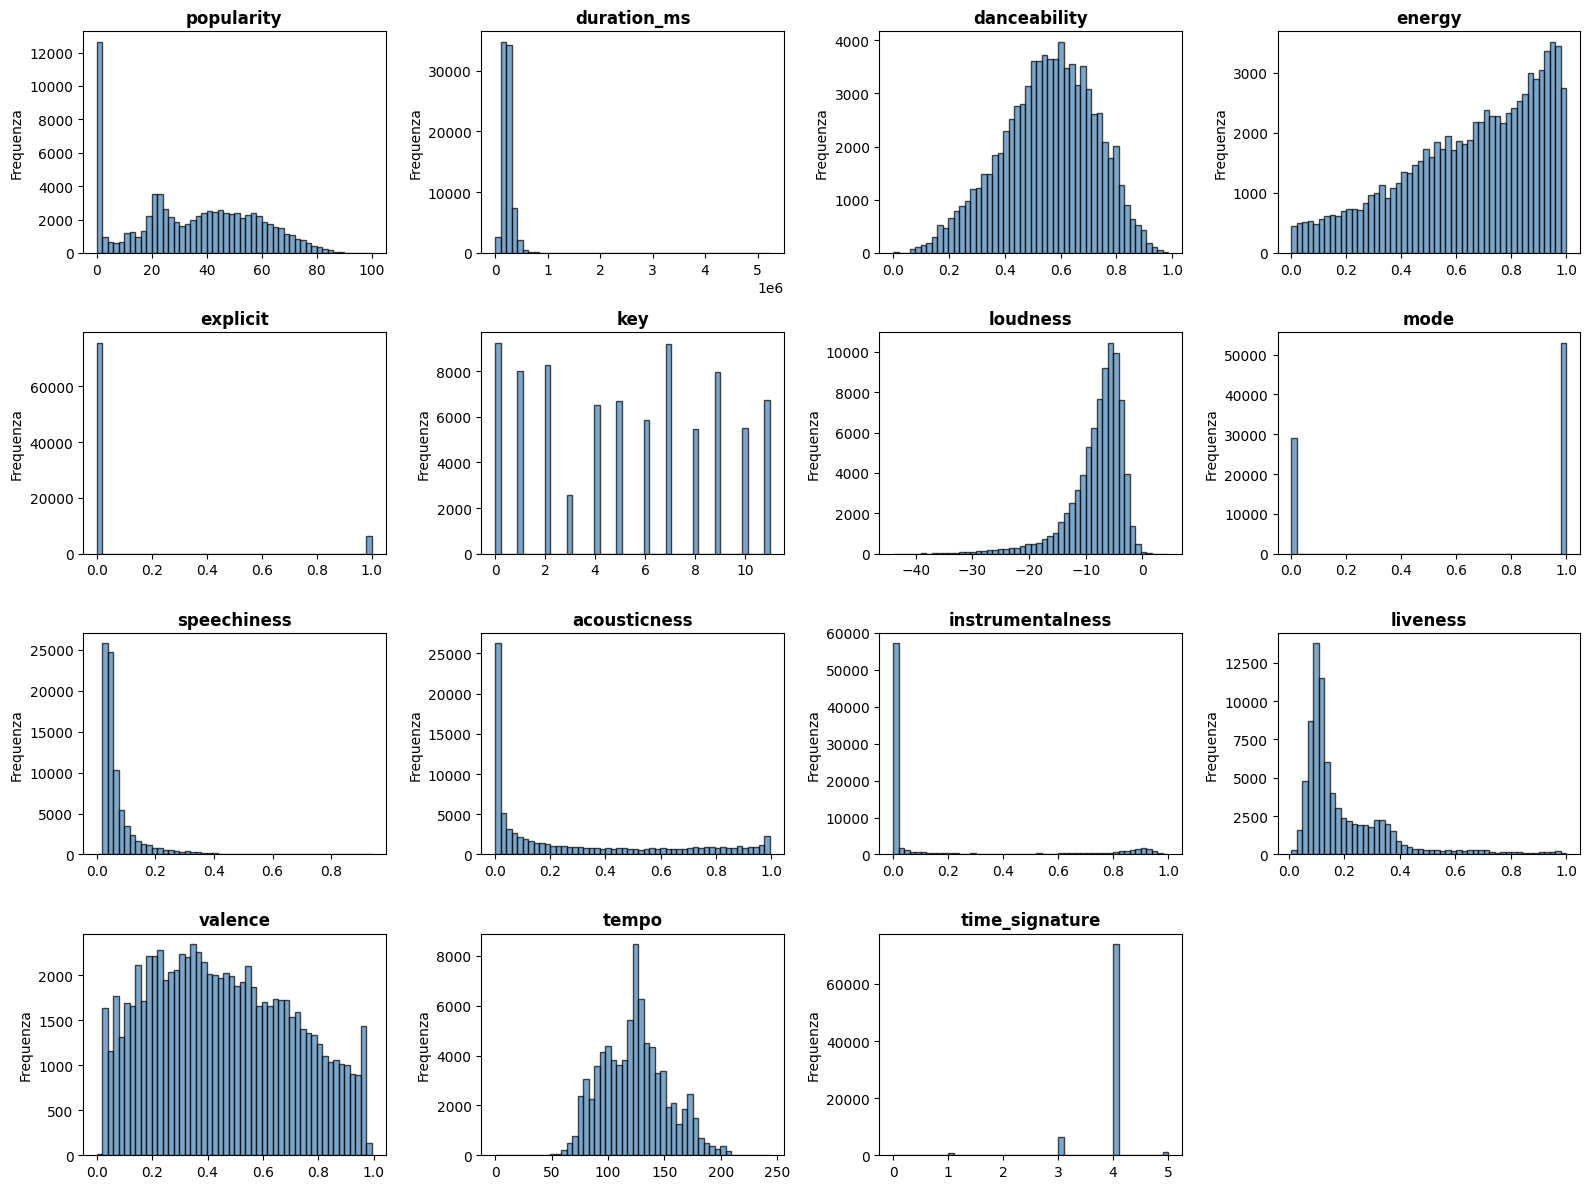

In [190]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    # Convert to integer inline so NumPy can calculate the bins
    axes[idx].hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].set_ylabel('Frequenza')
# Nascondi tutti gli assi che avanzano (dalla posizione 14 in poi)
for i in range(len(feature_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

Gli istogrammi mostrano le distribuzioni individuali di ogni feature.
-  **Energy** e **danceability** presentano distribuzioni relativamente uniformi con leggera concentrazione verso valori medio-alti, indicando varietà nei brani del dataset. 
- **Acousticness** e **instrumentalness** mostrano distribuzioni fortemente asimmetriche verso valori bassi, coerente con il predominio di musica elettronica e vocale nel dataset moderno. 
- **Valence** ha una distribuzione simile a quella di energy, ampia e diffusa. **Speechiness** è concentrata verso valori molto bassi con code lunghe, riflettendo il fatto che la maggior parte della musica non contiene parlato. 
- **Loudness** mostra una distribuzione approssimativamente normale centrata intorno a -5/-6 dB.
-  **Duration** ha una distribuzione con coda lunga, con la maggior parte delle tracce intorno ai 3-4 minuti ma con alcuni outliers molto lunghi.

Ci sono delle feature che si possono togliere:

- **liveness**: Questa variabile indica la probabilità che la traccia sia registrata dal vivo. Dall'analisi esplorativa è emerso che la stragrande maggioranza dei brani nel dataset presenta un valore prossimo allo zero (registrazioni in studio). Essendo una feature fortemente sbilanciata e non direttamente correlata alle caratteristiche timbriche o strutturali di un genere musicale, la sua inclusione rischierebbe di introdurre solo rumore (noise) nel modello, senza contribuire alla discriminazione tra le classi.
- **popularity**: Sebbene sia una metrica interessante per analisi di mercato, la popolarità è una variabile estrinseca al contenuto sonoro della traccia. Un brano può essere molto popolare o di nicchia all'interno di qualsiasi genere musicale; pertanto, includerla comporterebbe il rischio di "data leakage" (il modello potrebbe imparare a classificare i generi in base alla loro diffusione commerciale anziché alle loro proprietà acustiche), non aiutando a generalizzare le caratteristiche sonore del genere stesso.

In [191]:
df.drop(columns=['liveness', 'popularity'], inplace=True)

### Boxplot per feature principali per genere (Top 15)

Text(0.5, 0.98, '')

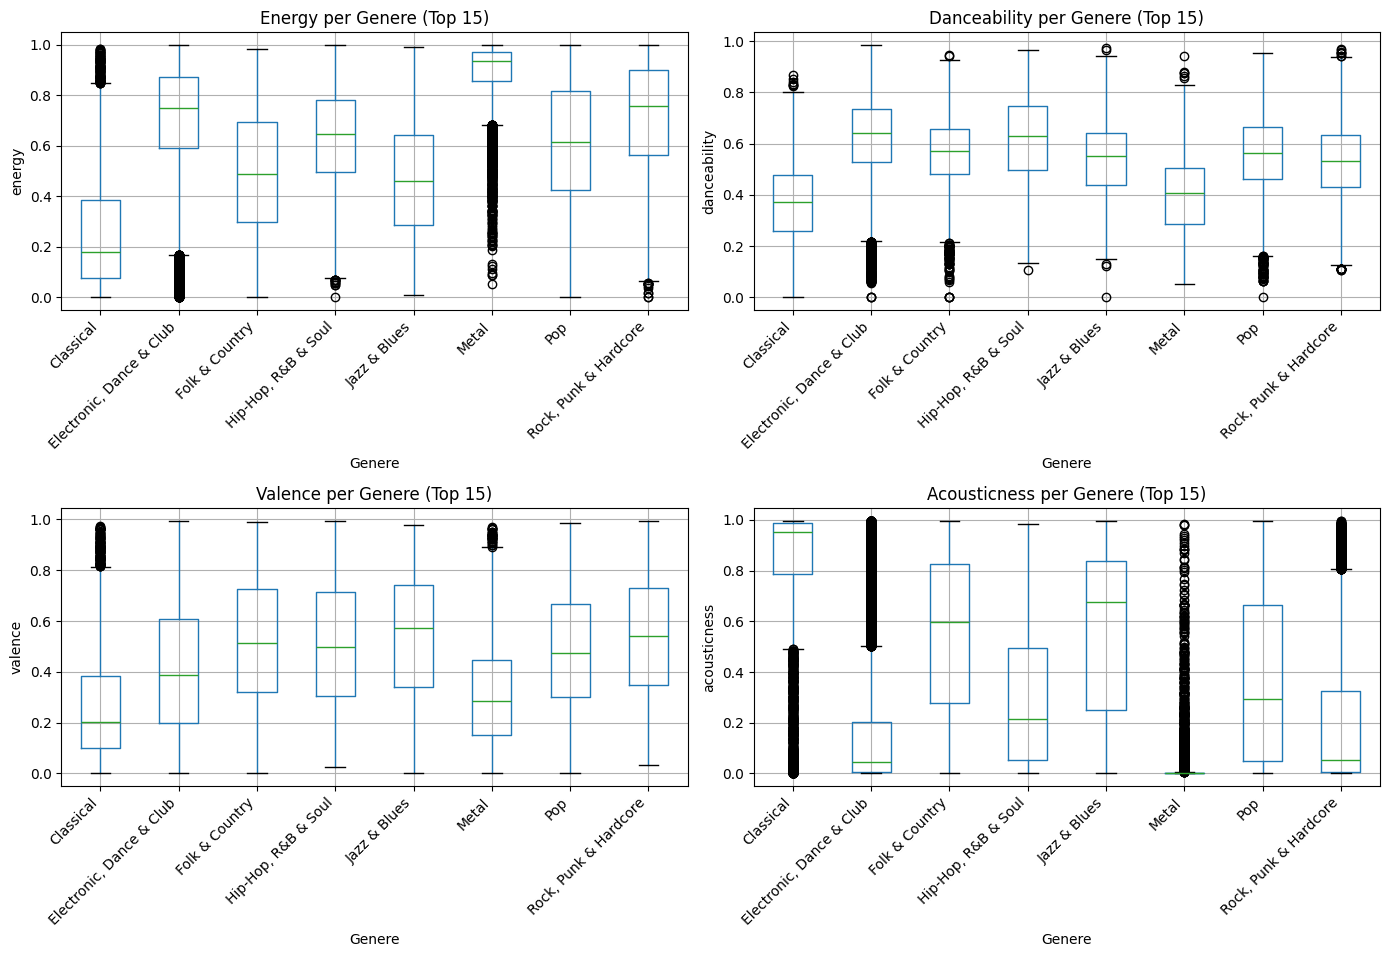

In [192]:
main_features = ['energy', 'danceability', 'valence', 'acousticness']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = np.array(axes, dtype=object)
if axes.ndim == 1 and axes.size == 4:
    axes = axes.reshape(2,2)
for idx, feature in enumerate(main_features):
    ax = axes[idx // 2, idx % 2]
    try:
        df.boxplot(column=feature, by='genre', ax=ax)
        ax.set_xlabel('Genere')
        ax.set_ylabel(feature)
        ax.set_title(f'{feature.capitalize()} per Genere (Top 15)')
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    except Exception as e:
        ax.text(0.5, 0.5, f'Errore plotting {feature}: {e}', ha='center')
plt.tight_layout()
plt.suptitle('')



I boxplot mostrano differenze significative nelle feature principali tra i generi. 
- Per la feature **energy**, si osserva che i generi rock e metal, hanno mediamente valori più alti, mentre generi come classical hanno valori bassi. 
- Per **danceability**, il pattern è simile: generi tipicamente danzabili (dance, house, pop) hanno mediane più alte rispetto a generi come classical o metal.
-  La feature **valence** mostra variabilità tra generi, con alcuni come happy o pop che tendono verso valori più alti. Per **acousticness**, il contrasto è molto evidente: generi come acoustic e folk hanno valori molto alti, mentre dance ed electronic hanno valori quasi nulli.

I boxplot evidenziano le differenze chiave tra i macro-generi:
- **Outlier**: La presenza massiccia di punti neri (es. in Electronic, Metal) è naturale: indica che, sebbene la maggior parte dei brani abbia caratteristiche omogenee (es. bassa acousticness), esistono eccezioni (brani acustici isolati) che vengono segnalate come anomalie statistiche.
- **Coerenza**:
Classical si conferma all'opposto di Dance/Electronic per Acousticness ed Energy.
Folk mostra la variabilità interna più alta (box più lunghi).
Punk/Hardcore e Rock mantengono profili energetici coerenti e distinti dal pop commerciale.

### Matrice di correlazione tra feature

Passiamo ora a visualizzare la correlazione tra le feature:

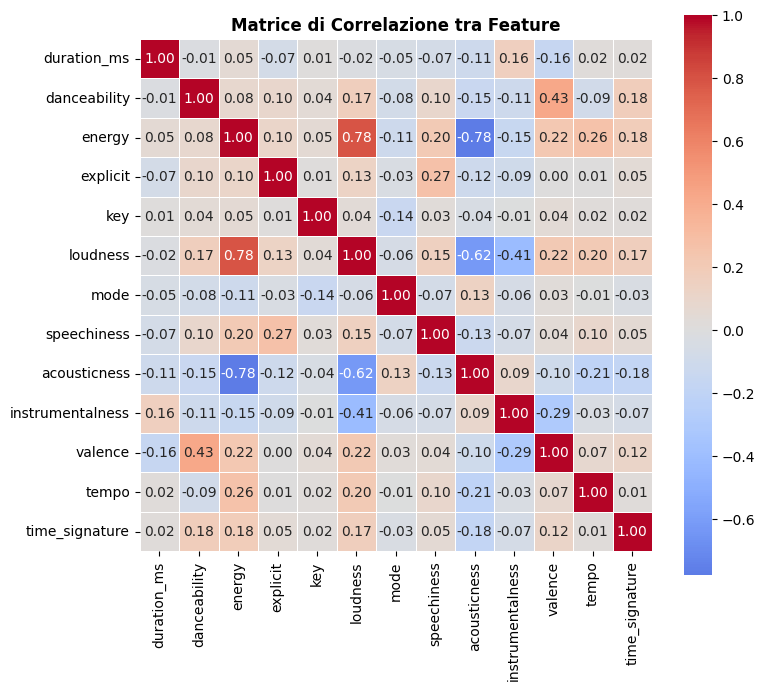

In [193]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()

fig, ax = plt.subplots(figsize=(8, 8))
sb.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
           square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Matrice di Correlazione tra Feature', fontweight='bold')
plt.tight_layout()
plt.show()

La matrice di correlazione rivela le relazioni lineari tra le feature. Le correlazioni più notevoli sono:
- **Energy e Loudness** (~0.70): correlazione positiva forte, naturale poiché brani energici tendono ad essere più forti
- **Acousticness e Energy** (~-0.60): correlazione negativa, coerente con il fatto che brani acustici sono tipicamente meno intensi
- **Valence e Energy** (~0.50): correlazione positiva moderata, suggerendo che brani energici tendono ad essere più positivi

Queste correlazioni moderate indicano che le feature catturano aspetti diversi della musica, il che è favorevole per il modello: una correlazione troppo alta comporterebbe ridondanza di informazione, mentre una correlazione troppo bassa suggerirebbe che le feature catturano fenomeni indipendenti.

### Correlazione di ogni feature con il genere

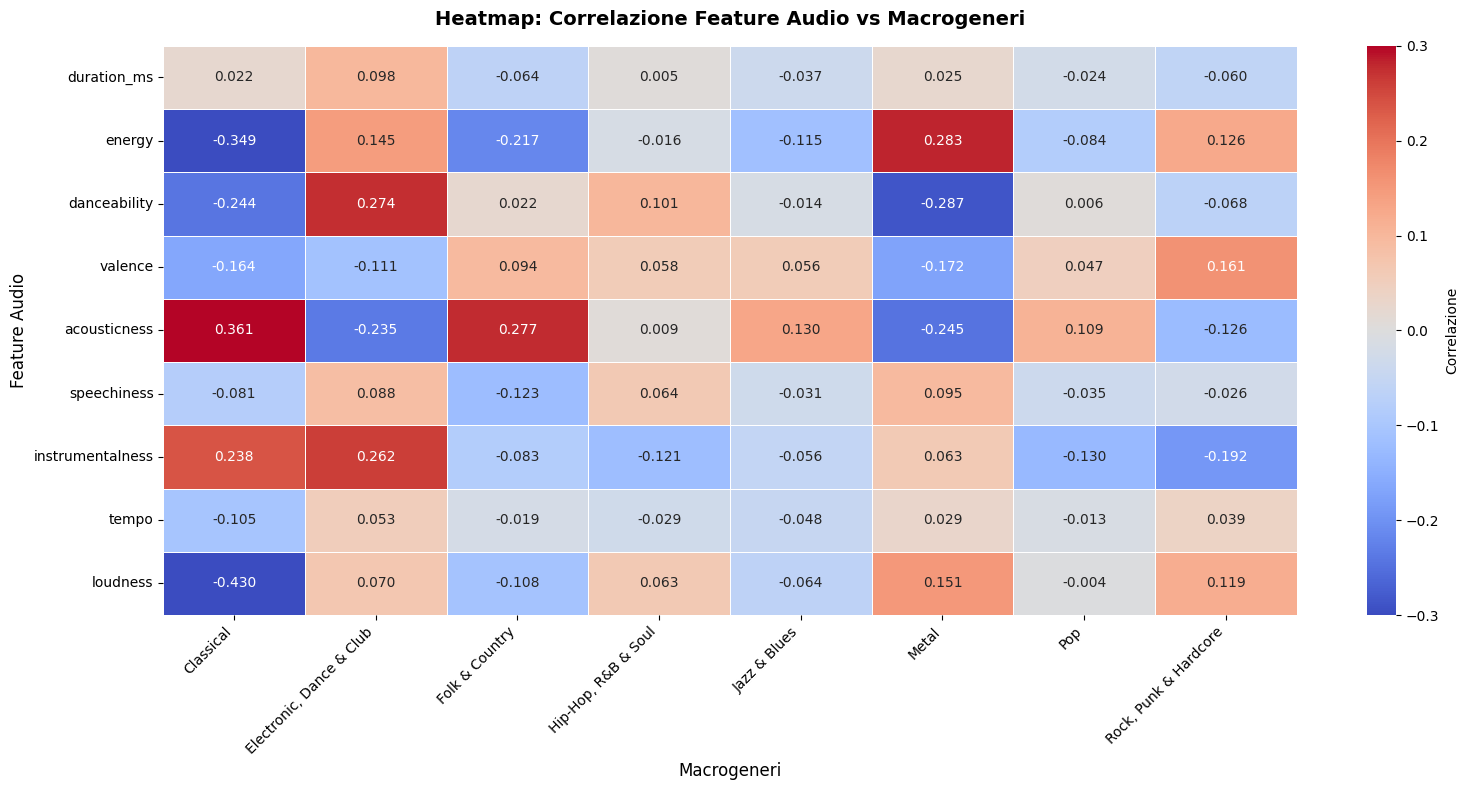

Heatmap delle correlazioni creata.


In [201]:
# Feature audio numeriche
audio_features = ['duration_ms', 'energy', 'danceability', 'valence', 'acousticness', 
                    'speechiness', 'instrumentalness', 'tempo', 'loudness']
audio_features = [f for f in audio_features if f in df.columns]

# One-hot encode i macrogeneri (colonna 'genre')
macro_dummies = pd.get_dummies(df['genre'], prefix='genre', drop_first=False)

# Calcola correlazione tra feature e macrogeneri binari
matrix_corr_data = {}
for feature in audio_features:
    correlations = {}
    for col in macro_dummies.columns:
        corr = df[feature].corr(macro_dummies[col])
        # Estrai il nome del genere dal nome della colonna (rimuovi il prefisso 'genre_')
        genre_name = col.replace('genre_', '')
        correlations[genre_name] = corr
    matrix_corr_data[feature] = correlations

# Crea DataFrame: feature su righe, generi su colonne
matrix_corr = pd.DataFrame(matrix_corr_data).T

# Plot heatmap
plt.figure(figsize=(16, 8))
sb.heatmap(
    matrix_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    linewidths=0.5,
    cbar_kws={'label': 'Correlazione'},
    vmin=-0.3, vmax=0.3
)
plt.title('Heatmap: Correlazione Feature Audio vs Macrogeneri', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Macrogeneri', fontsize=12)
plt.ylabel('Feature Audio', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Heatmap delle correlazioni creata.")



Un'osservazione critica: tutte le correlazioni individuali tra le feature e il genere sono basse. Ciò significa che **nessuna singola feature è in grado di predire il genere in modo univoco**. Questa è una caratteristica del problema che lo rende interessante e sfidante: il genere musicale non è determinato da una sola caratteristica fisica, ma dall'interazione di molteplici attributi.

Tuttavia, questo non è un problema per il nostro modello. I modelli di machine learning come Random Forest sono specificamente progettati per scoprire **combinazioni non-lineari** di feature che insieme hanno grande potere predittivo. Il fatto che le feature individuali abbiano bassa correlazione suggerisce che il modello avrà bisogno di catturare interazioni complesse tra le feature, il che rende il problema interessante dal punto di vista del learning.

Rimuoviamo eventuali rows con valori nulli:

In [202]:
df.isna().sum()

duration_ms         0
danceability        0
energy              0
explicit            0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
valence             0
tempo               0
time_signature      0
genre               0
dtype: int64

Prepariamo i dati per l'addestramento: separiamo variabili predittive e feature target.

In [203]:
y = df['genre']
X = df.drop(columns=['genre'])

Dividiamo ora in training e test set

In [204]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 20% al test set, 80% al training
    random_state=42,     # Per riproducibilità
    stratify=y           # <-- Stratificazione fondamentale!
)


Le classi restano sbilanciate dopo il raggruppamento in macrogeneri, quindi uso `class_weight='balanced'` nei modelli che lo supportano. In questo modo evito oversampling artificiale e mantengo il confronto piu` semplice e leggibile.


### Modello baseline casuale


Questo modello assegna le classi a caso ed e` solo un riferimento minimo: un modello utile deve superarlo in modo netto.


In [205]:
from sklearn.dummy import DummyClassifier

random_baseline = DummyClassifier(strategy='uniform', random_state=42)
random_baseline.fit(X_train, y_train)


,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'uniform'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


Il baseline casuale serve a capire se il modello sta davvero imparando segnale oppure solo rumore. Qui ci aspettiamo un'accuracy vicina al caso, quindi molto piu` bassa dei modelli veri.


### Modello 1: Logistic Regression (con Pipeline)

In [206]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logisticRegression = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced'))
])
logisticRegression.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may n

### Modello 2: RandomForest (con Pipeline)

In [207]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

randomForest = Pipeline([
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'))
])

randomForest.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.

### Modello 3: LightGBM (con Pipeline)

In [208]:
from lightgbm import LGBMClassifier

lgb = Pipeline([
    ('classifier', LGBMClassifier(n_estimators=100, verbose=-1, random_state=42, class_weight='balanced'))
])
lgb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None


### Confronto dei Modelli

Definiamo una funzione che stampi le metriche di valutazione:

In [209]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, top_k_accuracy_score
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test):
    # 1. Predizioni standard
    y_pred = model.predict(X_test)
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # 2. Calcolo metriche base
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # 3. FIX TOP-2 ACCURACY: Passiamo labels=model.classes_ per evitare i problemi di codifica
    probs = model.predict_proba(X_test)
    top2 = top_k_accuracy_score(y_test, probs, k=2, labels=model.classes_)
    print(f"Top-2 Accuracy: {top2:.4f}")
    
    # 4. Matrice di Confusione
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues', xticks_rotation=90)
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

Classification Report:
                          precision    recall  f1-score   support

               Classical       0.04      0.12      0.06       800
Electronic, Dance & Club       0.31      0.13      0.18      5000
          Folk & Country       0.11      0.12      0.12      1800
     Hip-Hop, R&B & Soul       0.07      0.12      0.09      1200
            Jazz & Blues       0.02      0.11      0.04       400
                   Metal       0.08      0.12      0.10      1400
                     Pop       0.15      0.12      0.13      2600
   Rock, Punk & Hardcore       0.19      0.12      0.15      3200

                accuracy                           0.12     16400
               macro avg       0.12      0.12      0.11     16400
            weighted avg       0.18      0.12      0.14     16400

Accuracy: 0.1224
Precision: 0.1820
Recall: 0.1224
F1 Score: 0.1368
Top-2 Accuracy: 0.3537


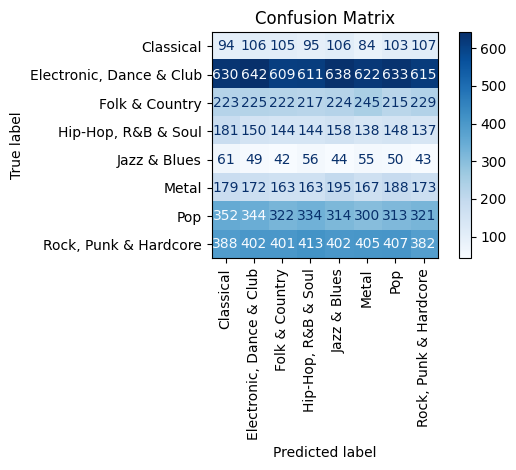

In [210]:
evaluate_model(random_baseline, X_test, y_test)

Classification Report:
                          precision    recall  f1-score   support

               Classical       0.43      0.70      0.53       800
Electronic, Dance & Club       0.74      0.46      0.57      5000
          Folk & Country       0.33      0.35      0.34      1800
     Hip-Hop, R&B & Soul       0.17      0.32      0.22      1200
            Jazz & Blues       0.10      0.40      0.16       400
                   Metal       0.41      0.76      0.54      1400
                     Pop       0.25      0.06      0.10      2600
   Rock, Punk & Hardcore       0.36      0.34      0.35      3200

                accuracy                           0.39     16400
               macro avg       0.35      0.42      0.35     16400
            weighted avg       0.44      0.39      0.38     16400

Accuracy: 0.3855
Precision: 0.4428
Recall: 0.3855
F1 Score: 0.3846
Top-2 Accuracy: 0.5861


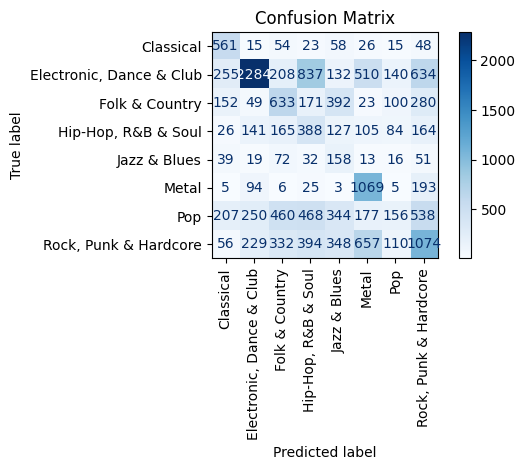

In [211]:
evaluate_model(logisticRegression, X_test, y_test)

La logistic regression supera il caso, ma resta il modello piu` debole tra quelli provati: la frontiera lineare cattura solo una parte della struttura del problema. Il fatto che il top-2 sia molto piu` alto dell'accuracy dice che spesso il genere corretto e` comunque tra le prime alternative suggerite.


Classification Report:
                          precision    recall  f1-score   support

               Classical       0.64      0.65      0.64       800
Electronic, Dance & Club       0.70      0.79      0.74      5000
          Folk & Country       0.61      0.63      0.62      1800
     Hip-Hop, R&B & Soul       0.51      0.35      0.41      1200
            Jazz & Blues       0.44      0.42      0.43       400
                   Metal       0.65      0.62      0.64      1400
                     Pop       0.51      0.48      0.49      2600
   Rock, Punk & Hardcore       0.53      0.51      0.52      3200

                accuracy                           0.61     16400
               macro avg       0.57      0.56      0.56     16400
            weighted avg       0.60      0.61      0.60     16400

Accuracy: 0.6064
Precision: 0.5988
Recall: 0.6064
F1 Score: 0.6005
Top-2 Accuracy: 0.7938


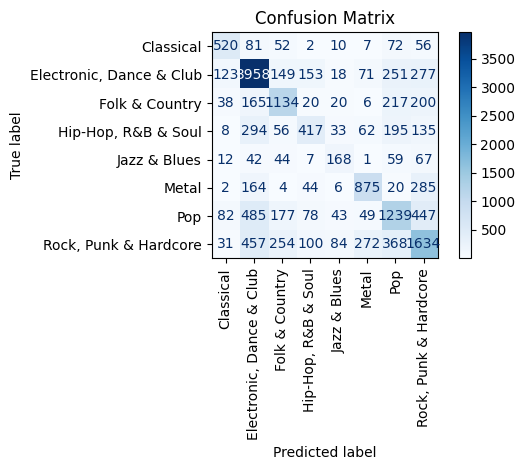

In [212]:
evaluate_model(randomForest, X_test, y_test)

La random forest e` il modello piu` solido del confronto base: guadagna parecchio rispetto alla logistic regression perche` gestisce meglio relazioni non lineari e interazioni tra feature. Rimane comunque piu` fragile sulle classi meno rappresentate, ma e` chiaramente il candidato migliore qui.


Classification Report:
                          precision    recall  f1-score   support

               Classical       0.51      0.74      0.60       800
Electronic, Dance & Club       0.80      0.61      0.69      5000
          Folk & Country       0.44      0.59      0.51      1800
     Hip-Hop, R&B & Soul       0.31      0.48      0.38      1200
            Jazz & Blues       0.24      0.50      0.33       400
                   Metal       0.53      0.79      0.64      1400
                     Pop       0.46      0.35      0.40      2600
   Rock, Punk & Hardcore       0.50      0.36      0.42      3200

                accuracy                           0.53     16400
               macro avg       0.47      0.55      0.49     16400
            weighted avg       0.56      0.53      0.53     16400

Accuracy: 0.5266
Precision: 0.5615
Recall: 0.5266
F1 Score: 0.5301
Top-2 Accuracy: 0.7292


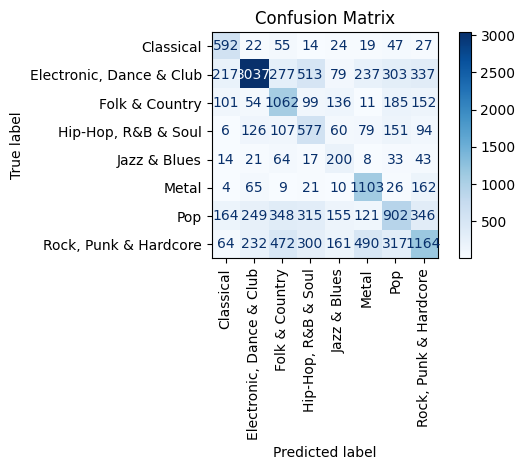

In [213]:
evaluate_model(lgb, X_test, y_test)

LightGBM e` competitivo, ma in questo setup non supera la random forest. Il risultato suggerisce che il problema e` gia` catturato bene da alberi ensemble e che ulteriori guadagni probabilmente richiedono tuning piu` fine o feature engineering migliore.


## Analisi dell'Importanza delle Feature
Esaminiamo quali feature sono più rilevanti per la predizione del genere musicale, confrontando i diversi modelli.

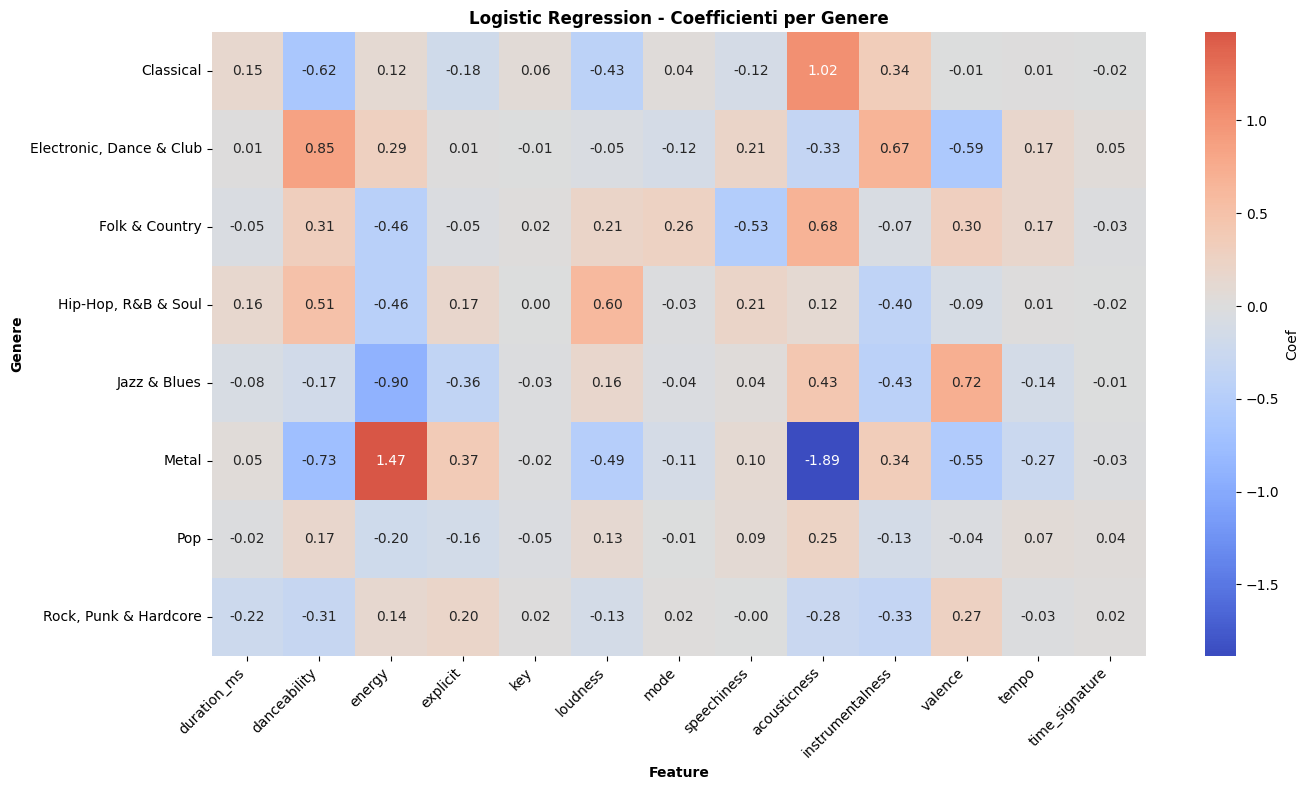

In [215]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

lr_model = logisticRegression.named_steps['classifier']

# Top 5 per genere
for i, g in enumerate(lr_model.classes_):
    coef = pd.DataFrame({
        'Feature': X_train.columns,
        'Coef': lr_model.coef_[i],
        'Abs': abs(lr_model.coef_[i])
    }).sort_values('Abs', ascending=False)

# Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(pd.DataFrame(lr_model.coef_, columns=X_train.columns, index=lr_model.classes_),
            annot=True, cmap='coolwarm', fmt='.2f', center=0, cbar_kws={'label': 'Coef'})
plt.title('Logistic Regression - Coefficienti per Genere', fontweight='bold')
plt.xlabel('Feature', fontweight='bold')
plt.ylabel('Genere', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

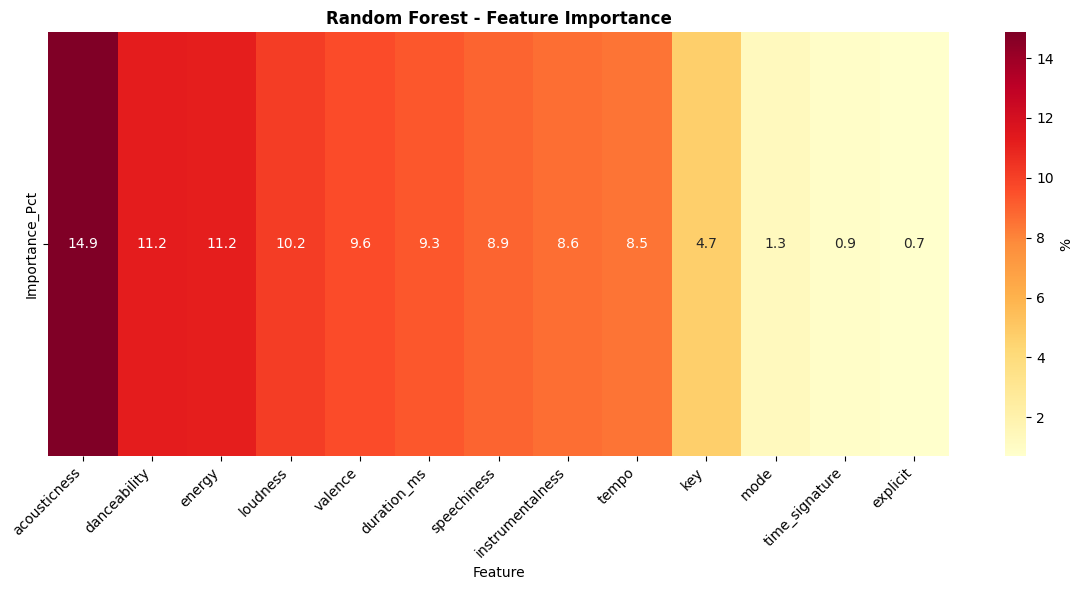

In [217]:
rf_model = randomForest.named_steps['classifier']

# Feature importance
fi = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_,
    'Importance_Pct': rf_model.feature_importances_ * 100
}).sort_values('Importance', ascending=False)

# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(fi.set_index('Feature')[['Importance_Pct']].T, 
            annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': '%'})
plt.title('Random Forest - Feature Importance', fontweight='bold')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

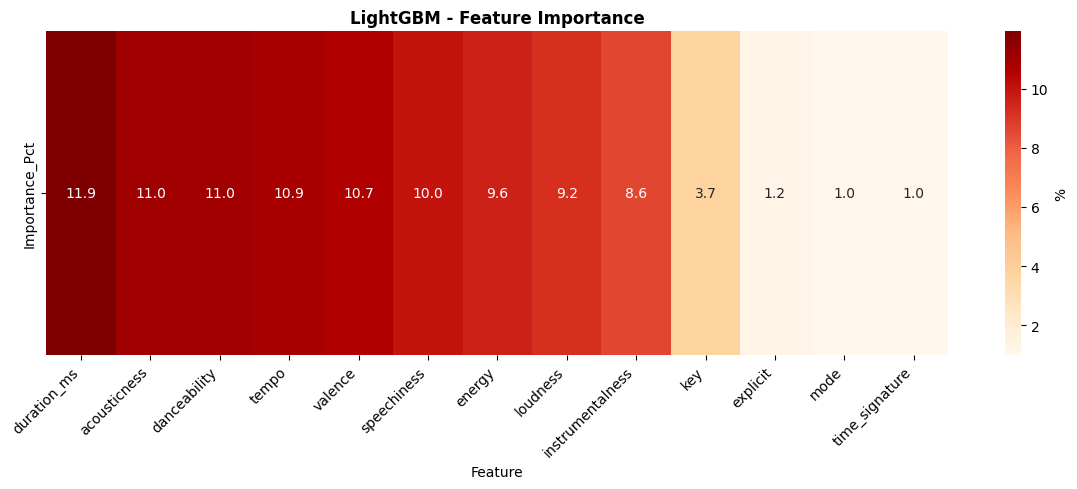

In [ ]:
lgb_model = lgb.named_steps['classifier']
fi_lgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_model.feature_importances_,
    'Importance_Pct': (lgb_model.feature_importances_ / lgb_model.feature_importances_.sum()) * 100
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 5))
sns.heatmap(fi_lgb.set_index('Feature')[['Importance_Pct']].T, annot=True, fmt='.1f', cmap='OrRd', cbar_kws={'label': '%'})
plt.title('LightGBM - Feature Importance', fontweight='bold')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Le feature piu` informative sono quelle legate a timbro e dinamica del brano: acousticness, danceability, valence, energy, loudness. Questo conferma che il modello sta usando proprieta` audio reali, non metadati, per distinguere i macro-generi.


In [ ]:
# Analisi coefficienti Logistic Regression
lr_model = logisticRegression.named_steps['classifier']

# Per classificazione multiclasse, visualizza i coefficienti della prima classe
coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print('Top feature - Logistic Regression (coefficienti):')
print(coeff_df.head(10))

Top feature - Logistic Regression (coefficienti):
             Feature  Coefficient
8       acousticness     0.678620
7        speechiness    -0.536258
2             energy    -0.480609
10           valence     0.316595
1       danceability     0.298192
6               mode     0.257831
5           loudness     0.219413
11             tempo     0.174149
9   instrumentalness    -0.072389
3           explicit    -0.068332


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

# Spazi di ricerca condivisi: servono sia per la nested CV sia per il modello finale
param_dist_lr = {
    'classifier__C': uniform(0.1, 10),
    'classifier__max_iter': randint(100, 1000),
    'classifier__solver': ['lbfgs', 'liblinear']
}

param_dist_rf = {
    'classifier__n_estimators': randint(50, 200),
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__min_samples_split': randint(2, 10)
}

param_dist_lgb = {
    'classifier__n_estimators': randint(50, 200),
    'classifier__max_depth': [5, 10, 20, 30],
    'classifier__learning_rate': uniform(0.01, 0.2),
    'classifier__num_leaves': randint(20, 100),
    'classifier__min_child_samples': randint(5, 30)
}

# Outer loop comune alla nested CV
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


## Nested Cross Validation
La faccio prima della search finale per misurare la robustezza dell'approccio senza usare il test set. Il tuning interno sceglie i parametri, il loop esterno stima quanto quel tuning generalizza davvero.


In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold

# Loop esterno: StratifiedKFold a 5 fold
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Salva i risultati per ogni fold
nested_cv_scores = []

print('Nested CV - Logistic Regression:')
fold = 0
for train_idx, test_idx in outer_cv.split(X_train, y_train):
    fold += 1
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[test_idx]
    
    # Loop interno: RandomizedSearchCV sul training fold
    inner_search = RandomizedSearchCV(
        logisticRegression,
        param_dist_lr,
        n_iter=5,
        cv=3,
        random_state=42,
        n_jobs=-1
    )
    inner_search.fit(X_tr, y_tr)
    
    # Valuta sul validation fold
    score = inner_search.score(X_val, y_val)
    nested_cv_scores.append(score)
    print(f'  Fold {fold}: {score:.4f}')

print(f'\nMedia Nested CV: {np.mean(nested_cv_scores):.4f} (+/- {np.std(nested_cv_scores):.4f})')

Nested CV - Logistic Regression:
  Fold 1: 0.3902
  Fold 2: 0.3972
  Fold 3: 0.3954
  Fold 4: 0.3834
  Fold 5: 0.3980

Media Nested CV: 0.3928 (+/- 0.0054)


In [ ]:
# Nested CV anche per Random Forest
nested_cv_scores_rf = []

print('\nNested CV - Random Forest:')
fold = 0
for train_idx, test_idx in outer_cv.split(X_train, y_train):
    fold += 1
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[test_idx]
    
    inner_search = RandomizedSearchCV(
        randomForest,
        param_dist_rf,
        n_iter=5,
        cv=3,
        random_state=42,
        n_jobs=-1
    )
    inner_search.fit(X_tr, y_tr)
    
    score = inner_search.score(X_val, y_val)
    nested_cv_scores_rf.append(score)
    print(f'  Fold {fold}: {score:.4f}')

print(f'\nMedia Nested CV: {np.mean(nested_cv_scores_rf):.4f} (+/- {np.std(nested_cv_scores_rf):.4f})')


Nested CV - Random Forest:
  Fold 1: 0.6002
  Fold 2: 0.5956
  Fold 3: 0.5979
  Fold 4: 0.6010
  Fold 5: 0.6013

Media Nested CV: 0.5992 (+/- 0.0022)


In [ ]:
# Nested CV anche per LightGBM
nested_cv_scores_lgb = []

print('\nNested CV - LightGBM:')
fold = 0
for train_idx, test_idx in outer_cv.split(X_train, y_train):
    fold += 1
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[test_idx]
    
    inner_search = RandomizedSearchCV(
        Pipeline([
            ('classifier', LGBMClassifier(verbose=-1, random_state=42))
        ]),
        param_dist_lgb,
        n_iter=5,
        cv=3,
        random_state=42,
        n_jobs=-1
    )
    inner_search.fit(X_tr, y_tr)
    
    # Test sul fold esterno
    best_model = inner_search.best_estimator_
    y_pred = best_model.predict(X_val)
    score = accuracy_score(y_val, y_pred)
    nested_cv_scores_lgb.append(score)
    print(f'Fold {fold}: Accuracy = {score:.4f}')

print(f'\nMedia Nested CV (LGB): {np.mean(nested_cv_scores_lgb):.4f} (+/- {np.std(nested_cv_scores_lgb):.4f})')


Nested CV - LightGBM:
Fold 1: Accuracy = 0.5941
Fold 2: Accuracy = 0.5929
Fold 3: Accuracy = 0.5931
Fold 4: Accuracy = 0.5971
Fold 5: Accuracy = 0.6019

Media Nested CV (LGB): 0.5958 (+/- 0.0034)


Nested CV e tuning non sono la stessa cosa: il tuning cerca parametri buoni, la nested CV quantifica quanto quel tuning generalizza davvero. Se usassi solo la random search sul training set e poi il test set finale, avresti gia` una pipeline valida; la nested CV aggiunge una stima piu` robusta e meno ottimistica della performance.


## Ricerca finale degli Iperparametri
Dopo aver visto che l'approccio regge alla nested CV, faccio una RandomizedSearchCV finale sul training set per ottenere il modello da confrontare e consegnare.


In [ ]:
# Random search su Logistic Regression
random_search_lr = RandomizedSearchCV(
    logisticRegression,
    param_dist_lr,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_lr.fit(X_train, y_train)
print(f'Miglior parametri LR: {random_search_lr.best_params_}')
print(f'Miglior score CV: {random_search_lr.best_score_:.4f}')


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Miglior parametri LR: {'classifier__C': np.float64(1.9182496720710063), 'classifier__max_iter': 376, 'classifier__solver': 'lbfgs'}
Miglior score CV: 0.3931


In [ ]:
# Valuta il modello ottimizzato su test set
y_pred_lr_opt = random_search_lr.predict(X_test)
lr_opt_score = accuracy_score(y_test, y_pred_lr_opt)
print(f'Accuracy test set (LR ottimizzato): {lr_opt_score:.4f}')

Accuracy test set (LR ottimizzato): 0.3937


In [ ]:
# Random search su Random Forest
param_dist_rf = {
    'classifier__n_estimators': randint(50, 200),
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__min_samples_split': randint(2, 10)
}

random_search_rf = RandomizedSearchCV(
    randomForest,
    param_dist_rf,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_rf.fit(X_train, y_train)
print(f'Miglior parametri RF: {random_search_rf.best_params_}')
print(f'Miglior score CV: {random_search_rf.best_score_:.4f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Miglior parametri RF: {'classifier__max_depth': None, 'classifier__min_samples_split': 6, 'classifier__n_estimators': 152}
Miglior score CV: 0.5990


In [ ]:
# Valuta il modello ottimizzato su test set
y_pred_rf_opt = random_search_rf.predict(X_test)
rf_opt_score = accuracy_score(y_test, y_pred_rf_opt)
print(f'Accuracy test set (RF ottimizzato): {rf_opt_score:.4f}')

Accuracy test set (RF ottimizzato): 0.6083


In [ ]:
# Random search su LightGBM
param_dist_lgb = {
    'classifier__n_estimators': randint(50, 200),
    'classifier__max_depth': [5, 10, 20, 30],
    'classifier__learning_rate': uniform(0.01, 0.2),
    'classifier__num_leaves': randint(20, 100),
    'classifier__min_child_samples': randint(5, 30)
}

random_search_lgb = RandomizedSearchCV(
    lgb,
    param_dist_lgb,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_lgb.fit(X_train, y_train)
print(f'Miglior parametri LGB: {random_search_lgb.best_params_}')
print(f'Miglior score CV: {random_search_lgb.best_score_:.4f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Miglior parametri LGB: {'classifier__learning_rate': np.float64(0.12973169683940733), 'classifier__max_depth': 20, 'classifier__min_child_samples': 23, 'classifier__n_estimators': 124, 'classifier__num_leaves': 94}
Miglior score CV: 0.5775


In [ ]:
# Valuta il modello ottimizzato su test set
y_pred_lgb_opt = random_search_lgb.predict(X_test)
lgb_opt_score = accuracy_score(y_test, y_pred_lgb_opt)
print(f'Accuracy test set (LGB ottimizzato): {lgb_opt_score:.4f}')

Accuracy test set (LGB ottimizzato): 0.5788


La ricerca degli iperparametri cambia poco i risultati: la logistic regression resta invariata, mentre random forest e LightGBM migliorano solo marginalmente. Questo vuol dire che i modelli base erano gia` abbastanza vicini al loro plateau sul dataset.
